Output folder created/verified: report02_forPDFReport
1. DATA LOADING
Shape: (41188, 21)

First 5 rows:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1

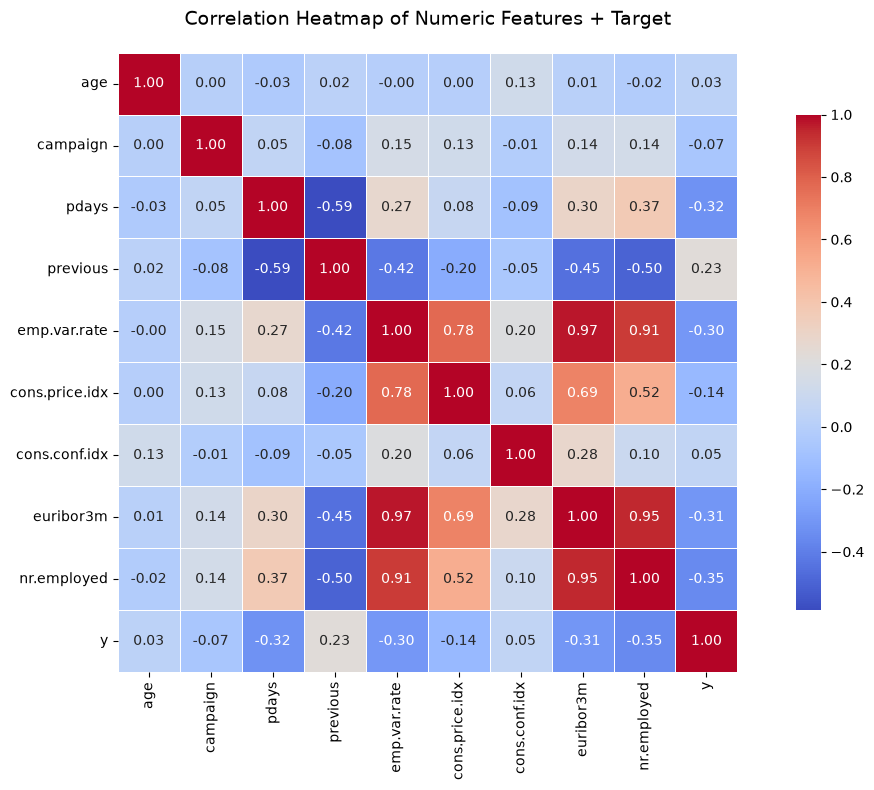

Correlation heatmap saved as 'report02_forPDFReport/correlation_heatmap.png'

6. LOGISTIC REGRESSION
Training set size: 28831
Test set size:     12357

7. MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.86      0.90     10965
         Yes       0.36      0.65      0.46      1392

    accuracy                           0.83     12357
   macro avg       0.66      0.75      0.68     12357
weighted avg       0.88      0.83      0.85     12357


Confusion Matrix:
[[9382 1583]
 [ 492  900]]

ROC-AUC Score: 0.8029

8. TOP FEATURE COEFFICIENTS

Top 15 most influential features:
                 feature  coefficient  abs_coefficient
            emp.var.rate    -2.203492         2.203492
          cons.price.idx     0.991535         0.991535
               euribor3m     0.700903         0.700903
       contact_telephone    -0.300079         0.300079
was_previously_contacted     0.267457         0.267457
              

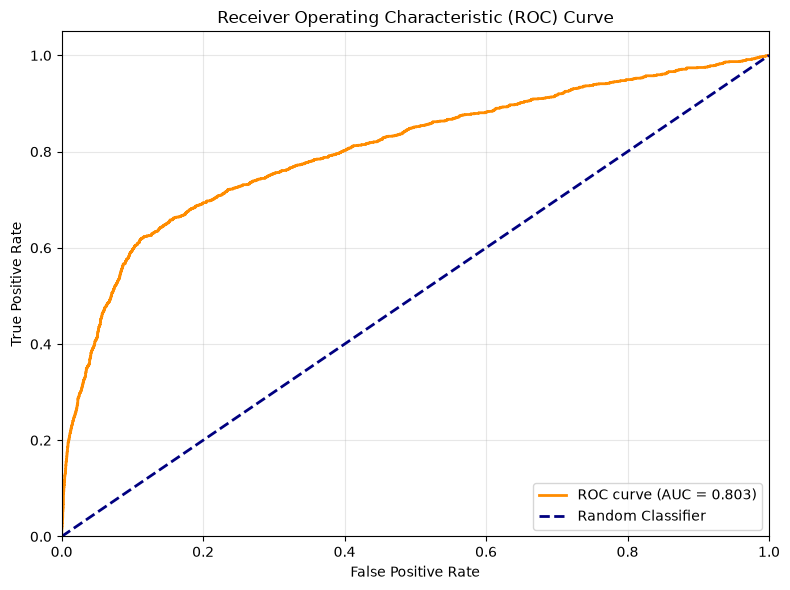

ROC curve saved as 'report02_forPDFReport/roc_curve.png'

ANALYSIS COMPLETE
ROC-AUC Score          : 0.8029
Overall Conversion Rate: 11.27%

Files saved in folder 'report02_forPDFReport':
  - bank_cleaned.csv
  - correlation_heatmap.png
  - logistic_coefficients.csv
  - roc_curve.png


In [2]:
# ==============================================================
# Bank Marketing Analysis - Complete Script
# Includes: Data Cleaning + Correlation Heatmap + Logistic Regression
# ==============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# --------------------------------------------------------------
# Create output folder
# --------------------------------------------------------------
output_folder = "report02_forPDFReport"
os.makedirs(output_folder, exist_ok=True)
print(f"Output folder created/verified: {output_folder}")

# --------------------------------------------------------------
# 1. Load Data
# --------------------------------------------------------------
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("="*60)
print("1. DATA LOADING")
print("="*60)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nTarget distribution:")
print(df['y'].value_counts(normalize=True))

# --------------------------------------------------------------
# 2. Basic Quality Checks
# --------------------------------------------------------------
print("\n" + "="*60)
print("2. QUALITY CHECKS")
print("="*60)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# --------------------------------------------------------------
# 3. Data Cleaning & Feature Engineering
# --------------------------------------------------------------
# Convert target to binary
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Create derived features
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 30, 45, 60, 100],
                         labels=['young', 'mid', 'senior', 'elderly'])

# Save cleaned data
df.to_csv(os.path.join(output_folder, 'bank_cleaned.csv'), index=False)
print(f"\nCleaned data saved as '{output_folder}/bank_cleaned.csv'")

# --------------------------------------------------------------
# 4. Descriptive Statistics
# --------------------------------------------------------------
print("\n" + "="*60)
print("4. DESCRIPTIVE STATISTICS")
print("="*60)
print("\nNumeric variables:")
print(df.describe())
print("\nCategorical variables:")
print(df.describe(include='object'))

# --------------------------------------------------------------
# 5. Correlation Heatmap
# --------------------------------------------------------------
print("\n" + "="*60)
print("5. CORRELATION HEATMAP")
print("="*60)

numeric_cols = ['age', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed', 'y']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Features + Target', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Correlation heatmap saved as '{output_folder}/correlation_heatmap.png'")

# --------------------------------------------------------------
# 6. Logistic Regression
# --------------------------------------------------------------
print("\n" + "="*60)
print("6. LOGISTIC REGRESSION")
print("="*60)

# Select features (exclude duration to avoid data leakage)
feature_cols = ['age', 'campaign', 'previous', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'euribor3m',
                'nr.employed', 'was_previously_contacted']

# One-hot encode categorical variables
cat_cols = ['job', 'marital', 'education', 'default', 'housing',
            'loan', 'contact', 'month', 'day_of_week', 'poutcome']

df_model = pd.get_dummies(df[feature_cols + cat_cols + ['y']],
                          columns=cat_cols,
                          drop_first=True)

X = df_model.drop('y', axis=1)
y = df_model['y']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression with class balancing
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# --------------------------------------------------------------
# 7. Model Evaluation
# --------------------------------------------------------------
print("\n" + "="*60)
print("7. MODEL EVALUATION")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# --------------------------------------------------------------
# 8. Feature Importance (Coefficients)
# --------------------------------------------------------------
print("\n" + "="*60)
print("8. TOP FEATURE COEFFICIENTS")
print("="*60)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print("\nTop 15 most influential features:")
print(coef_df.head(15).to_string(index=False))

# Save coefficients to CSV
coef_df.to_csv(os.path.join(output_folder, 'logistic_coefficients.csv'), index=False)
print(f"\nCoefficients saved as '{output_folder}/logistic_coefficients.csv'")

# --------------------------------------------------------------
# 9. ROC Curve
# --------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC curve saved as '{output_folder}/roc_curve.png'")

# --------------------------------------------------------------
# 10. Final Summary
# --------------------------------------------------------------
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"ROC-AUC Score          : {roc_auc:.4f}")
print(f"Overall Conversion Rate: {df['y'].mean():.2%}")

print("\nFiles saved in folder 'report02_forPDFReport':")
print("  - bank_cleaned.csv")
print("  - correlation_heatmap.png")
print("  - logistic_coefficients.csv")
print("  - roc_curve.png")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# 1. Load data
# Reads the CSV using semicolon (;) as separator (this is how the original file is formatted).
# Why sep=';'? The official dataset uses semicolons, not commas. Using the default comma would produce a single broken column.
df = pd.read_csv('bank-additional-full.csv', sep=';') 

print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df['y'].value_counts(normalize=True))

# 2. Basic quality checks
print("\nMissing values:\n", df.isnull().sum())          # none (unknown is used)
print("\nDuplicate rows:", df.duplicated().sum())

# 3. Handle "unknown" as a category (no imputation needed)
# Already coded as "unknown" – keep as is (justified: informative missingness)

# 4. Convert target
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 5. Create derived features (optional but useful)
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100],
                         labels=['young', 'mid', 'senior', 'elderly'])

# 6. Save cleaned version
df.to_csv('1) bank_cleaned.csv', index=False)
print("Cleaned data saved.")

Matplotlib is building the font cache; this may take a moment.


Shape: (41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  eur

In [ ]:
# Loads all libraries needed for the full pipeline (cleaning → EDA → modelling → evaluation).
# pandas + numpy → standard for tabular data manipulation.
import pandas as pd
import numpy as np
# matplotlib + seaborn → static visualisations (heatmaps, distributions).
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn → consistent, production-style modelling and metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# statsmodels → more detailed statistical output (p-values, confidence intervals) if needed later.
import statsmodels.api as sm

# warnings.filterwarnings('ignore') → suppresses non-critical deprecation/runtime warnings so the notebook stays readable.
import warnings
warnings.filterwarnings('ignore')

# 1. Load data
df = pd.read_csv('bank-additional-full.csv', sep=';')
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df['y'].value_counts(normalize=True))
# Why print these four things immediately?
# Shape → confirm we have the expected ~41 188 rows.
# head() → visual sanity check.
# info() → confirm data types and that there are no pure nulls.
# value_counts(normalize=True) → immediately see the class imbalance (~11 % “yes”).

# 2. Basic quality checks
print("\nMissing values:\n", df.isnull().sum()) # Checks for true NaN missing values.
print("\nDuplicate rows:", df.duplicated().sum()) # Checks for exact duplicate rows.

# 3. Handle "unknown" as a category (no imputation needed)
# Already coded as "unknown" – keep as is (justified: informative missingness)

# 4. Convert target
df['y'] = df['y'].map({'yes': 1, 'no': 0}) # Converts the string labels "yes" / "no" into integers 1 / 0.
# Why this approach? Almost every scikit-learn and statsmodels classifier expects a numeric binary target. Mapping is explicit, reversible, and easy to understand.
    
# 5. Create derived features (optional but useful)
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100],
                         labels=['young', 'mid', 'senior', 'elderly'])
# What does this code does?
# Creates a clean binary flag indicating whether the client was contacted in a previous campaign (pdays == 999 means “never contacted”).
# Bins continuous age into meaningful life-stage groups.

# 6. Save cleaned version
df.to_csv('1) bank_cleaned.csv', index=False)
print("Cleaned data saved.")
# Writes the cleaned DataFrame to a new CSV without the pandas index column.